# 62 — Is the FFT signal itself the problem?

Notebook 61 ruled out mask sparsity: `--out-h/--out-w` cannot change occupancy (BOX downsampling
conserves mass), and one-cube at 16x16 is *sparser* than the mix that already failed. So the
question moves to the **input signal**.

For `experiment-25` (trains) vs `31_07_2026_gastronorm_exp1` (predicts nothing), we ask:

1. **How diverse** is the signal across samples at all?
2. **How much does it vary with position** — the thing the model must decode?
3. **How much is it dominated by speaker** — the nuisance variable?
4. Is position information **recoverable** by a simple probe (kNN / linear), i.e. is it present
   at all before we blame the transformer?

The headline metric is a **variance decomposition**: for each grouping factor, what fraction of
the total between-sample variance in the signal does it explain? A dataset where position
explains ~0% is a dataset where no model can learn position.

In [2]:
import json
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd().parent / "src"))
from model.dataset import process_vibration

EXP_ROOT = Path.cwd().parent / "experiments"
PATCH_SIZE = 256
pd.set_option("display.width", 220, "display.max_columns", 60)

# The two datasets use different on-disk schemes and different position-label keys.
DATASETS = {
    "exp25 (trains)": dict(
        root=EXP_ROOT / "experiment-25",
        smask="image/02_smask.png",
        pos_key="output_id",     # exp25 labels position with output_id
    ),
    "gastronorm (fails)": dict(
        root=EXP_ROOT / "31_07_2026_gastronorm_exp1",
        smask="images/03_smask.png",
        pos_key="position_id",   # gastronorm labels position with position_id
    ),
}
FFT = "vibration/03_fft.npz"

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 0. Load both datasets

We load the **clean** (unaugmented) signal exactly as the eval loaders see it:
`|fft| -> normalize(std) -> tokenize`, then flatten back to a per-sample feature vector.
We keep two representations per sample:

- `spec` — mean magnitude over lasers, i.e. a per-frequency spectrum `(F,)`. Cheap, good for
  plots and for speaker structure.
- `feat` — the full flattened `(L*F*C,)` clean signal, subsampled in frequency to keep memory
  sane. This is what the position probes run on, since position should live in the
  *per-laser* pattern, not the average spectrum.

In [3]:
def meta_of(d: Path) -> dict:
    return {k: v for l in open(d / "metadata.jsonl") for k, v in json.loads(l).items()}

def sample_dirs(cfg):
    return [d for d in sorted((cfg["root"] / "samples").glob("*"))
            if (d / FFT).exists() and (d / cfg["smask"]).exists()]

FREQ_STRIDE = 4  # subsample frequency for the flattened feature vector

def load_dataset(name, cfg, limit=None):
    dirs = sample_dirs(cfg)
    if limit: dirs = dirs[:limit]
    rows, specs, feats = [], [], []
    for d in tqdm(dirs, desc=name):
        m = meta_of(d)
        z = np.load(d / FFT)
        fft, freqs = z["fft"], z["freqs"]
        if fft.ndim == 4 and fft.shape[0] == 1: fft = fft[0]      # (L,F,C)

        x = torch.from_numpy(fft).unsqueeze(0)
        clean = process_vibration(x, torch.from_numpy(freqs), "magnitude", "std", 0, augment=0.0)
        clean = clean.squeeze(0).numpy()                            # (L,F,C), patch_size=0 -> no tokenize

        mag = np.abs(fft)
        rows.append({
            "dataset": name, "dir": d,
            "sample_id": m.get("sample_id"),
            "speaker": m.get("speaker"),
            "layout": m.get("layout"),
            "position": str(m.get(cfg["pos_key"])),
            "n_objects": m.get("n_objects"),
            "raw_mag_mean": mag.mean(), "raw_mag_std": mag.std(),
            "clean_mean": clean.mean(), "clean_std": clean.std(), "clean_max": clean.max(),
        })
        specs.append(clean.mean(axis=(0, 2)))                       # (F,)
        feats.append(clean[:, ::FREQ_STRIDE, :].ravel())            # (L*F/stride*C,)
    return pd.DataFrame(rows), np.array(specs), np.array(feats, dtype=np.float32)

In [4]:
data = {}
for name, cfg in DATASETS.items():
    df, spec, feat = load_dataset(name, cfg)
    data[name] = dict(df=df, spec=spec, feat=feat, cfg=cfg)
    print(f"{name:>20}: {len(df)} samples | spec {spec.shape} | feat {feat.shape}")

exp25 (trains):   0%|          | 0/1024 [00:00<?, ?it/s]

      exp25 (trains): 1024 samples | spec (1024, 2946) | feat (1024, 147400)


gastronorm (fails):   0%|          | 0/3007 [00:00<?, ?it/s]

  gastronorm (fails): 3007 samples | spec (3007, 1235) | feat (3007, 61800)


In [5]:
for name, d in data.items():
    df = d["df"]
    print(f"\n=== {name}")
    print(f"  speakers : {df.speaker.nunique()}  {sorted(df.speaker.unique())}")
    print(f"  positions: {df.position.nunique()} (key={d['cfg']['pos_key']})")
    print(f"  layouts  : {df.layout.nunique()}")
    print(f"  samples per position: mean={df.groupby('position').size().mean():.1f} "
          f"min={df.groupby('position').size().min()} max={df.groupby('position').size().max()}")


=== exp25 (trains)
  speakers : 8  [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  positions: 128 (key=output_id)
  layouts  : 4
  samples per position: mean=8.0 min=8 max=8

=== gastronorm (fails)
  speakers : 8  [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  positions: 376 (key=position_id)
  layouts  : 11
  samples per position: mean=8.0 min=7 max=8


## 1. Raw diversity — is there *any* variation across samples?

Before asking what explains the variance, check there is variance to explain.

In [6]:
div = []
for name, d in data.items():
    f = d["feat"]
    # correlation between every pair of samples (subsample for cost)
    idx = np.random.default_rng(0).choice(len(f), size=min(300, len(f)), replace=False)
    F = f[idx]
    Fz = (F - F.mean(1, keepdims=True)) / (F.std(1, keepdims=True) + 1e-9)
    C = (Fz @ Fz.T) / Fz.shape[1]
    off = C[~np.eye(len(C), dtype=bool)]
    div.append({
        "dataset": name,
        "feat_dim": f.shape[1],
        "mean_pairwise_corr": off.mean(),
        "std_pairwise_corr": off.std(),
        "cv_of_clean_std": d["df"].clean_std.std() / d["df"].clean_std.mean(),
    })
div_df = pd.DataFrame(div).set_index("dataset")
div_df

,feat_dim,mean_pairwise_corr,std_pairwise_corr,cv_of_clean_std
dataset,,,,
exp25 (trains),147400,0.266492,0.116858,6.735744e-08
gastronorm (fails),61800,0.824857,0.090113,4.449197e-08


`mean_pairwise_corr` near 1.0 means every sample looks like every other sample — no diversity.
Lower is more diverse. `std_pairwise_corr` says how much that similarity itself varies (a
dataset with structure has some pairs much more similar than others).

In [7]:
def effective_rank(F, k=200):
    """exp(entropy of the normalized PCA spectrum) -- how many directions the data really uses."""
    idx = np.random.default_rng(0).choice(len(F), size=min(400, len(F)), replace=False)
    X = F[idx] - F[idx].mean(0)
    s = np.linalg.svd(X, compute_uv=False)[:k]
    p = s ** 2 / (s ** 2).sum()
    p = p[p > 0]
    return float(np.exp(-(p * np.log(p)).sum()))

for name, d in data.items():
    print(f"{name:>20}: effective rank = {effective_rank(d['feat']):.1f}")

      exp25 (trains): effective rank = 95.2
  gastronorm (fails): effective rank = 11.2


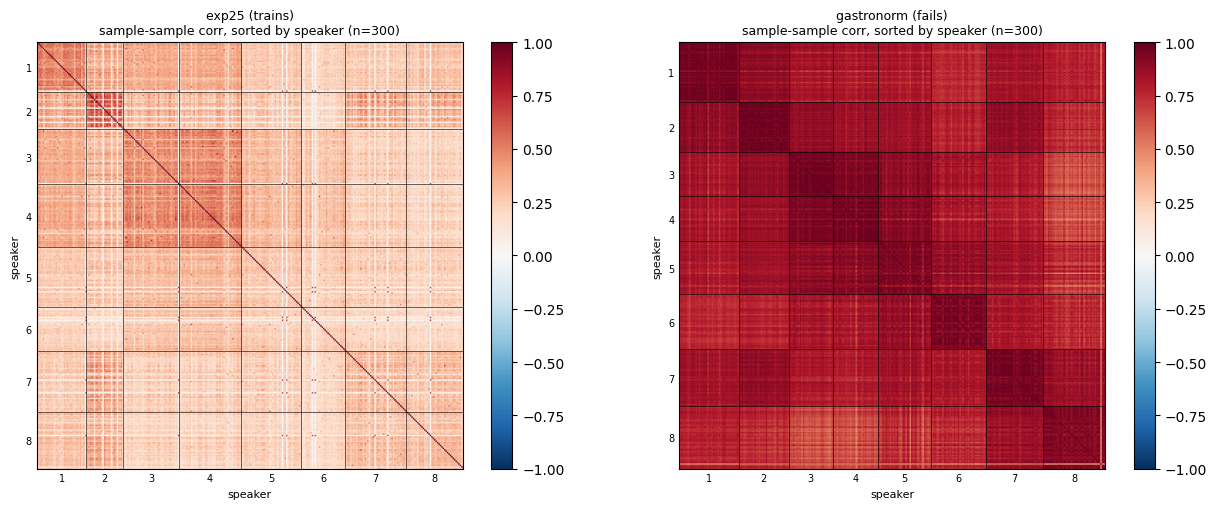

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, (name, d) in zip(axes, data.items()):
    idx = np.random.default_rng(0).choice(len(d["feat"]), size=min(300, len(d["feat"])), replace=False)
    F = d["feat"][idx]
    Fz = (F - F.mean(1, keepdims=True)) / (F.std(1, keepdims=True) + 1e-9)
    spk = d["df"].iloc[idx]["speaker"].values
    order = np.argsort(spk, kind="stable")          # stable, so blocks stay contiguous
    spk_sorted = spk[order]
    C = (Fz[order] @ Fz[order].T) / Fz.shape[1]
    im = ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)

    # speaker block boundaries: where the sorted speaker label changes
    labels, starts = np.unique(spk_sorted, return_index=True)
    o = np.argsort(starts); labels, starts = labels[o], starts[o]
    edges = np.append(starts, len(spk_sorted))      # block b spans [edges[b], edges[b+1])

    for e in edges[1:-1]:                            # interior boundaries only
        ax.axhline(e - 0.5, color="k", lw=0.6, alpha=0.7)
        ax.axvline(e - 0.5, color="k", lw=0.6, alpha=0.7)

    centers = (edges[:-1] + edges[1:]) / 2 - 0.5
    ax.set_xticks(centers); ax.set_xticklabels(labels, fontsize=7)
    ax.set_yticks(centers); ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel("speaker", fontsize=8); ax.set_ylabel("speaker", fontsize=8)
    ax.tick_params(length=0)

    ax.set_title(f"{name}\nsample-sample corr, sorted by speaker (n={len(idx)})", fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

Block structure along the diagonal = the signal is organized by **speaker**. If the blocks are
crisp and everything off-block is near zero, speaker identity dominates and position is a faint
residual.

## 2. Variance decomposition — speaker vs position vs layout

This is the core measurement. For a scalar summary `col`, the fraction of total variance
explained by a grouping is `Var(group means) / Var(all)`. We extend it to the full feature
vector by averaging over dimensions (equivalent to a multivariate eta-squared).

In [22]:
def eta_sq_vec(F: np.ndarray, labels: np.ndarray) -> float:
    """Fraction of total variance in F explained by `labels` (multivariate eta^2)."""
    labels = np.asarray(labels)
    total = F.var(axis=0).sum()
    if total <= 0: return np.nan
    grand = F.mean(axis=0)
    between = 0.0
    for lv in np.unique(labels):
        m = labels == lv
        between += m.sum() * ((F[m].mean(axis=0) - grand) ** 2).sum()
    return float(between / len(F) / total)

In [23]:
rows = []
for name, d in data.items():
    df, F = d["df"], d["feat"]
    for factor in ["speaker", "position", "layout", "n_objects"]:
        if df[factor].nunique() < 2: continue
        rows.append({"dataset": name, "factor": factor,
                     "n_levels": df[factor].nunique(),
                     "var_explained": eta_sq_vec(F, df[factor].values)})
var_df = pd.DataFrame(rows).pivot(index="factor", columns="dataset", values="var_explained")
print("fraction of between-sample signal variance explained by each factor:\n")
var_df.style.format("{:.1%}") if False else var_df.round(4)

fraction of between-sample signal variance explained by each factor:



dataset,exp25 (trains),gastronorm (fails)
factor,,
layout,0.0438,0.0421
n_objects,0.0423,0.0288
position,0.2858,0.2027
speaker,0.1569,0.6563


**Caveat — `n_levels` inflates `eta^2`.** A factor with many levels explains more variance by
chance alone (with N levels and n samples, chance level is roughly `(N-1)/(n-1)`). Position has
far more levels than speaker, so compare against the chance baseline, not against zero.

In [24]:
rows = []
for name, d in data.items():
    df, F = d["df"], d["feat"]
    rng = np.random.default_rng(0)
    for factor in ["speaker", "position", "layout"]:
        if df[factor].nunique() < 2: continue
        obs = eta_sq_vec(F, df[factor].values)
        # shuffle the labels to get the chance level for this many levels / this group-size profile
        null = np.mean([eta_sq_vec(F, rng.permutation(df[factor].values)) for _ in range(5)])
        rows.append({"dataset": name, "factor": factor, "n_levels": df[factor].nunique(),
                     "observed": obs, "chance": null, "ratio_over_chance": obs / null if null else np.nan})
adj = pd.DataFrame(rows)
adj.round(4)

,dataset,factor,n_levels,observed,chance,ratio_over_chance
0,exp25 (trains),speaker,8,0.1569,0.0066,23.7008
1,exp25 (trains),position,128,0.2858,0.1250,2.2860
2,exp25 (trains),layout,4,0.0438,0.0029,15.2796
3,gastronorm (fails),speaker,8,0.6563,0.0017,375.2010
4,gastronorm (fails),position,376,0.2027,0.1298,1.5613
5,gastronorm (fails),layout,11,0.0421,0.0037,11.4872


`ratio_over_chance` is the honest number. ~1.0 means the factor explains no more than random
labels would — i.e. **no real structure**. Substantially above 1.0 means genuine signal.

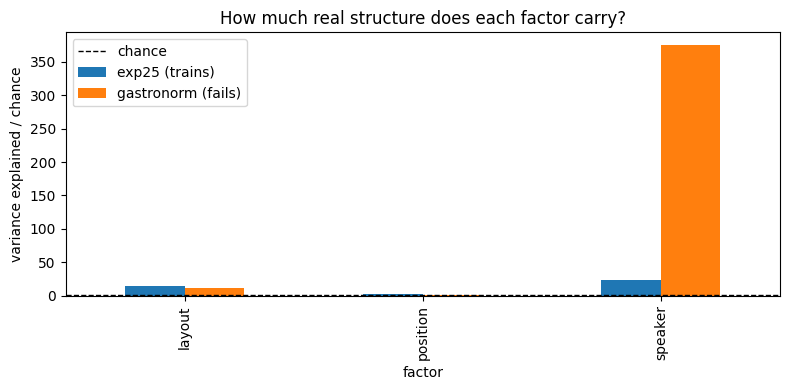

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
piv = adj.pivot(index="factor", columns="dataset", values="ratio_over_chance")
piv.plot.bar(ax=ax)
ax.axhline(1.0, color="k", ls="--", lw=1, label="chance")
ax.set_ylabel("variance explained / chance")
ax.set_title("How much real structure does each factor carry?")
ax.legend()
plt.tight_layout()

## 3. Position structure, with speaker held fixed

Speaker may swamp position globally. The fair test is **within a single speaker**: does the
signal still vary with position? This removes the nuisance variable entirely.

In [13]:
rows = []
for name, d in data.items():
    df, F = d["df"], d["feat"]
    for spk in sorted(df.speaker.dropna().unique()):
        m = (df.speaker == spk).values
        sub, Fs = df[m], F[m]
        if sub.position.nunique() < 2 or len(sub) < 20: continue
        obs = eta_sq_vec(Fs, sub.position.values)
        null = np.mean([eta_sq_vec(Fs, np.random.default_rng(i).permutation(sub.position.values)) for i in range(3)])
        rows.append({"dataset": name, "speaker": spk, "n": len(sub),
                     "n_positions": sub.position.nunique(),
                     "pos_var_explained": obs, "chance": null, "ratio": obs / null if null else np.nan})
within = pd.DataFrame(rows)
within.groupby("dataset")[["pos_var_explained", "chance", "ratio"]].mean().round(4)

,pos_var_explained,chance,ratio
dataset,,,
exp25 (trains),1.0,1.0,1.0
gastronorm (fails),1.0,1.0,1.0


In [14]:
within.round(4)

,dataset,speaker,n,n_positions,pos_var_explained,chance,ratio
0,exp25 (trains),1,128,128,1.0,1.0,1.0
1,exp25 (trains),2,128,128,1.0,1.0,1.0
2,exp25 (trains),3,128,128,1.0,1.0,1.0
3,exp25 (trains),4,128,128,1.0,1.0,1.0
4,exp25 (trains),5,128,128,1.0,1.0,1.0
5,exp25 (trains),6,128,128,1.0,1.0,1.0
6,exp25 (trains),7,128,128,1.0,1.0,1.0
7,exp25 (trains),8,128,128,1.0,1.0,1.0
8,gastronorm (fails),1,375,375,1.0,1.0,1.0
9,gastronorm (fails),2,376,376,1.0,1.0,1.0


## 4. Can a simple probe recover position from the signal?

Variance decomposition can miss structure that is real but low-variance. A direct test: hold out
samples and try to predict position from the signal with **kNN** (nonparametric, no training) and
a **linear** probe. If neither can beat the majority-class baseline, the information is not
there in a usable form — and no amount of transformer tuning will help.

To keep it fair across datasets we restrict to positions with enough samples and balance the
number of classes.

In [15]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

MIN_PER_POS = 6

def probe(name, d, target="position", control_speaker=None):
    df, F = d["df"], d["feat"]
    if control_speaker is not None:
        m = (df.speaker == control_speaker).values
        df, F = df[m], F[m]
    counts = df[target].value_counts()
    keep_lv = counts[counts >= MIN_PER_POS].index
    m = df[target].isin(keep_lv).values
    df, F = df[m], F[m]
    if df[target].nunique() < 2: return None
    # factorize to ints -- StratifiedKFold rejects object-dtype labels ('unknown' target type)
    y = pd.factorize(df[target].astype(str))[0]
    baseline = counts[keep_lv].max() / counts[keep_lv].sum()
    n_splits = min(5, int(df[target].value_counts().min()))
    if n_splits < 2: return None
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    out = {"dataset": name, "target": target, "speaker": control_speaker,
           "n": len(df), "n_classes": df[target].nunique(), "majority_baseline": baseline}
    # n_components must fit the smallest TRAIN fold, not the full set
    n_train = len(df) - len(df) // n_splits
    n_pca = max(2, min(50, n_train - 1, F.shape[1]))
    F = np.ascontiguousarray(F, dtype=np.float64)
    knn = make_pipeline(StandardScaler(), PCA(n_components=n_pca, random_state=0),
                        KNeighborsClassifier(n_neighbors=3))
    out["knn_acc"] = cross_val_score(knn, F, y, cv=cv, n_jobs=-1).mean()
    lin = make_pipeline(StandardScaler(), PCA(n_components=n_pca, random_state=0),
                        LogisticRegression(max_iter=2000, C=1.0))
    out["linear_acc"] = cross_val_score(lin, F, y, cv=cv, n_jobs=-1).mean()
    return out

### 4a. Predict **speaker** from the signal (sanity check — should be easy)

In [16]:
res = [probe(name, d, target="speaker") for name, d in data.items()]
spk_probe = pd.DataFrame([r for r in res if r])
spk_probe.round(3)

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed 

,dataset,target,speaker,n,n_classes,majority_baseline,knn_acc,linear_acc
0,exp25 (trains),speaker,None,1024,8,0.125,0.542,0.821
1,gastronorm (fails),speaker,None,3007,8,0.125,0.993,0.997


### 4b. Predict **position** from the signal (the thing that matters)

In [17]:
res = [probe(name, d, target="position") for name, d in data.items()]
pos_probe = pd.DataFrame([r for r in res if r])
pos_probe.round(3)

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed 

KeyboardInterrupt: 

### 4c. Predict position **within a single speaker** (nuisance removed)

In [ ]:
rows = []
for name, d in data.items():
    for spk in sorted(d["df"].speaker.dropna().unique())[:4]:
        r = probe(name, d, target="position", control_speaker=spk)
        if r: rows.append(r)
pos_within = pd.DataFrame(rows)
pos_within.round(3)

""


In [ ]:
if len(pos_within):
    summ = pos_within.groupby("dataset")[["majority_baseline", "knn_acc", "linear_acc"]].mean()
    summ["knn_lift"] = summ.knn_acc / summ.majority_baseline
    summ["linear_lift"] = summ.linear_acc / summ.majority_baseline
    print("within-speaker position decoding, averaged over speakers:")
    print(summ.round(3))

**Lift near 1.0 = position is not decodable from the signal.** That is the decisive result: if
gastronorm's lift is ~1 and exp25's is well above 1, the gastronorm capture simply does not
encode object position in the vibration measurement, and the model correctly falls back to
predicting the mean (which, at 1% occupancy, is ~nothing).

## 5. Where in frequency does the information live?

Per-frequency variance decomposition: for each frequency bin, how much does position explain
vs. speaker? Shows whether position information is concentrated in a band the model might be
discarding (recall notebook 61: `patch_size=256` truncates gastronorm at 838 Hz).

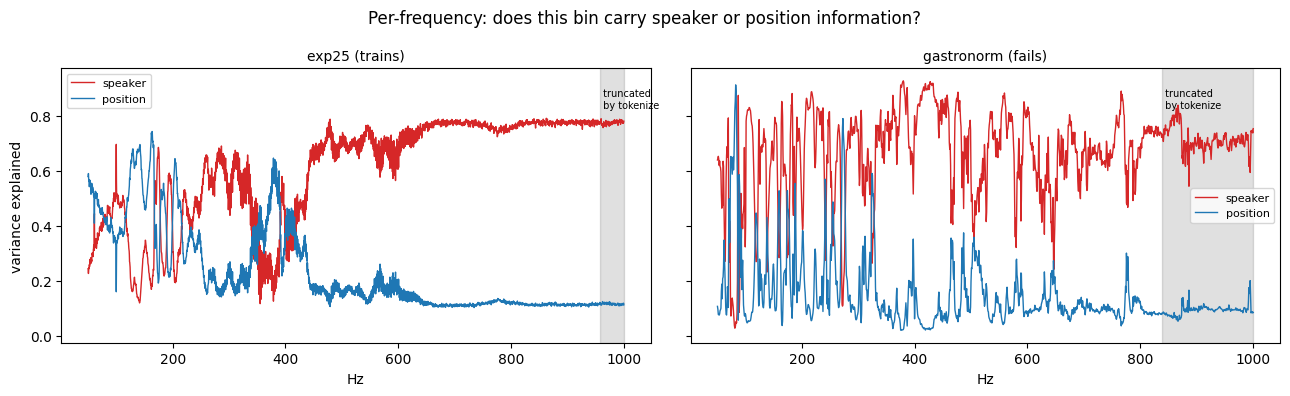

In [ ]:
def per_freq_eta(spec, labels):
    labels = np.asarray(labels)
    total = spec.var(axis=0)
    grand = spec.mean(axis=0)
    between = np.zeros_like(grand)
    for lv in np.unique(labels):
        m = labels == lv
        between += m.sum() * (spec[m].mean(axis=0) - grand) ** 2
    return between / len(spec) / np.maximum(total, 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (name, d) in zip(axes, data.items()):
    freqs = np.load(d["df"]["dir"].iloc[0] / FFT)["freqs"]
    for factor, c in [("speaker", "tab:red"), ("position", "tab:blue")]:
        ax.plot(freqs, per_freq_eta(d["spec"], d["df"][factor].values), label=factor, color=c, lw=1)
    n_f = len(freqs)
    kept = (n_f // PATCH_SIZE) * PATCH_SIZE
    if kept < n_f:
        ax.axvspan(freqs[kept], freqs[-1], color="k", alpha=0.12)
        ax.text(freqs[kept], 0.9, " truncated\n by tokenize", fontsize=7, va="top")
    ax.set_title(name, fontsize=10); ax.set_xlabel("Hz"); ax.legend(fontsize=8)
axes[0].set_ylabel("variance explained")
plt.suptitle("Per-frequency: does this bin carry speaker or position information?")
plt.tight_layout()

## 6. Do nearby positions produce nearby signals?

The model must learn a smooth map from signal to spatial layout. Test the precondition: is the
distance between two samples' signals related to the distance between their object positions?
We use each sample's mask center-of-mass as ground-truth position.

In [ ]:
from PIL import Image
from model.dataset import downsample_mask

def coms(d, n=250):
    df = d["df"].reset_index(drop=True)   # positional index, so sel.index indexes feat directly
    sel = df.sample(min(n, len(df)), random_state=0)
    out = []
    for _, r in sel.iterrows():
        y = downsample_mask(Image.open(r["dir"] / d["cfg"]["smask"]), 30, 30)
        if y.sum() <= 0: out.append((np.nan, np.nan)); continue
        yy, xx = np.mgrid[:30, :30]
        out.append(((y * yy).sum() / y.sum(), (y * xx).sum() / y.sum()))
    return sel, np.array(out)

from scipy.stats import spearmanr

for name, d in data.items():
    sel, com = coms(d)
    ok = ~np.isnan(com).any(1)
    sel, com = sel[ok], com[ok]
    F = d["feat"][sel.index.values]      # sel.index is positional after the reset above
    Fz = (F - F.mean(1, keepdims=True)) / (F.std(1, keepdims=True) + 1e-9)
    sig_d = 1 - (Fz @ Fz.T) / Fz.shape[1]
    pos_d = np.linalg.norm(com[:, None, :] - com[None, :, :], axis=-1)
    iu = np.triu_indices(len(com), 1)
    rho, p = spearmanr(sig_d[iu], pos_d[iu])
    # within-speaker version
    same_spk = sel.speaker.values[:, None] == sel.speaker.values[None, :]
    mask = np.triu(np.ones_like(same_spk), 1).astype(bool) & same_spk
    rho_w, _ = spearmanr(sig_d[mask], pos_d[mask])
    print(f"{name:>20}: signal-distance vs position-distance  rho={rho:+.3f} (p={p:.1e})  "
          f"within-speaker rho={rho_w:+.3f}   n={len(com)}")

      exp25 (trains): signal-distance vs position-distance  rho=+0.081 (p=8.5e-45)  within-speaker rho=+0.088   n=244
  gastronorm (fails): signal-distance vs position-distance  rho=+0.088 (p=3.4e-52)  within-speaker rho=+0.215   n=244


A positive `rho` means samples with objects in similar places have similar signals — the
smoothness the model needs. `rho ~ 0` means the signal geometry is unrelated to the spatial
geometry.

## Summary

Fill in from the numbers above. The decisive comparisons are:

- **§2 `ratio_over_chance` for `position`** — is position structure real in each dataset?
- **§4c within-speaker decoding lift** — is position *recoverable*, with speaker controlled?
- **§6 rho** — is the signal-to-position map smooth?

If gastronorm is at chance on all three and exp25 is clearly above, the problem is the capture,
not the model or the loss.